#### NBA 농구선수 게임 데이터를 활용한 포지션 예측을 위한 데이터 정제
- NBA 농구 선수들의 게임 기록을 데이터로 사용해서 특정 농구 선수의 포지션을 예측

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('../Data/basketball.csv')
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


- EDA를 통해 필요한 데이터만을 찾는다

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  100 non-null    object 
 1   Pos     100 non-null    object 
 2   3P      100 non-null    float64
 3   2P      100 non-null    float64
 4   TRB     100 non-null    float64
 5   AST     100 non-null    float64
 6   STL     100 non-null    float64
 7   BLK     100 non-null    float64
dtypes: float64(6), object(2)
memory usage: 6.4+ KB


#### Column Description
- Player : 선수 이름
- Pos : 포지션 (SG - Shooting Guard, C - Center)
- 3P : 한 경기당 평균 3점슛 성공 횟수
- 2P : 한 경기당 평균 2점슛 성공 횟수
- TRB : 한 경기당 평균 리바운드 성공 횟수
- AST : 한 경기당 평균 어시스트 성공 횟수 
- STL : 한 경기당 평균 스틸 성공 횟수
- BLK : 한 경기당 평균 블로킹 성공 횟수

In [4]:
# Target 데이터가 공평한지 확인한다
df.Pos.value_counts()

Pos
SG    50
C     50
Name: count, dtype: int64

#### 포지션별 내용
- C : Center는 골대나 포스트 근처에서 슛을 블로킹하고, 리바운드하며, 바깥으로 쳐내며,     
  골대 근처에서 2점슛으로 득점을 하기도 한다.
- SG : Shooting Guard는 코트 내에서 3점슛 등 장거리 슛을 하여 점수를 얻는 역할을 한다.

#### 데이터 시각화를 통한 EDA(탐색적 데이터 분석) 실시
: 데이터의 특징을 바탕으로 한 공간에 시각화 함으로써, 머신러닝 학습에 필요한 Feature와 불필요한 Feature를 쉽게 구분

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

### 스틸, 2점슛 데이터 시각화


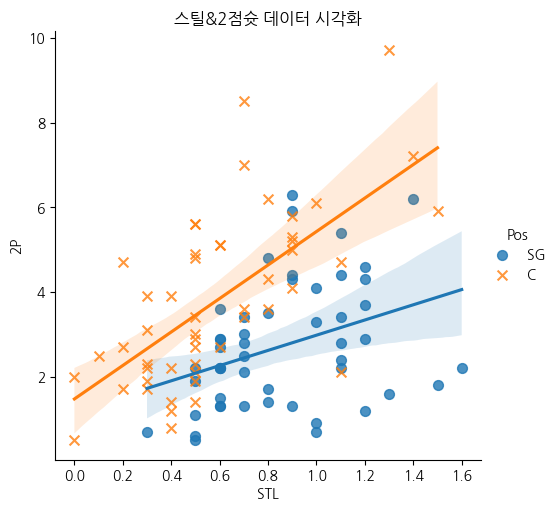

In [7]:
# seaborn
sns.lmplot(
    x='STL',
    y='2P',
    data=df,
    fit_reg=True, # 회귀선
    scatter_kws={'s': 50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('스틸&2점슛 데이터 시각화')

plt.show()

> 스틸과 2점슛의 속성으로 데이터를 분포시킬 경우, 슈팅가드와 센터의 경계가 너무 근접해서 분류하기 모호하다.

### 어시스트와 2점슛

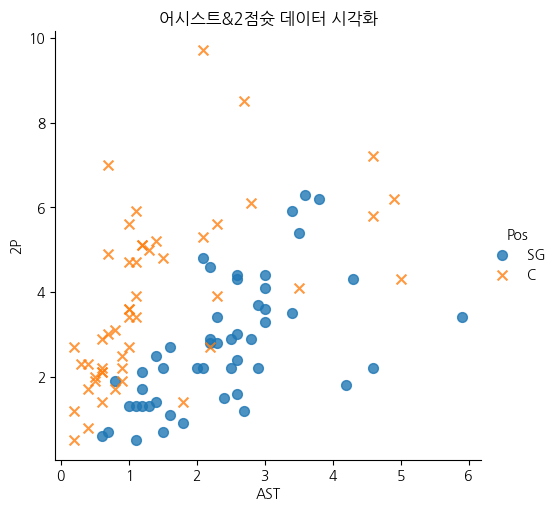

In [8]:
sns.lmplot(
    x='AST',
    y='2P',
    data=df,
    fit_reg=False,
    scatter_kws={'s': 50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('어시스트&2점슛 데이터 시각화')

plt.show()

> 어시스트와 2점슛의 속성으로 데이터를 분포 시킬 경우 슈팅가드와 센터의 경계가 너무 근접해서 분류하기에 모호다다.
> 단, 스티로가 2점슛의 속사ㅇ바든 잣다

#### 블로킹과 3점슛 데이터 시각화

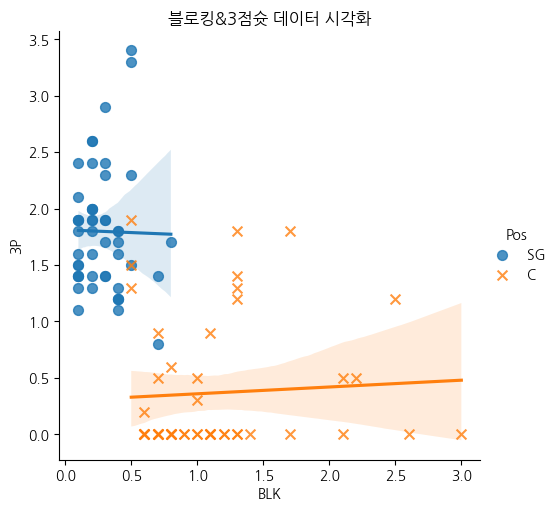

In [10]:
sns.lmplot(
    x='BLK',
    y='3P',
    data=df,
    fit_reg=True,
    scatter_kws={'s': 50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('블로킹&3점슛 데이터 시각화')

plt.show()

### 리바운드와 3점슛

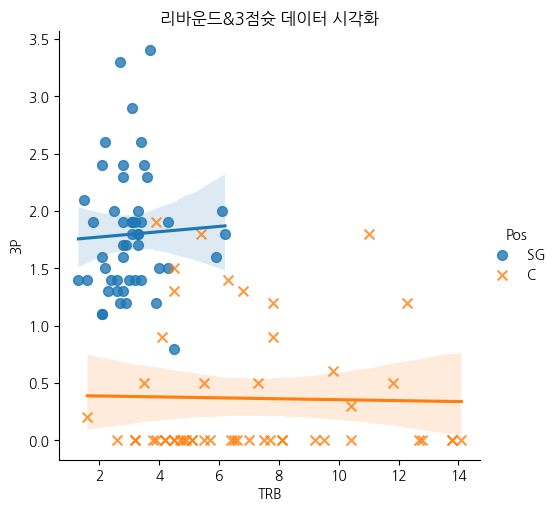

In [12]:
sns.lmplot(
    x='TRB',
    y='3P',
    data=df,
    fit_reg=True,
    scatter_kws={'s': 50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('리바운드&3점슛 데이터 시각화')

plt.show()

> EDA(Explorary Data Analysis) : 탐색적 데이터 분석 결과
- 분별력이 없는 Feature를 데이터에서 제거하기 위해 시각화를 해본 결과,     
  2P, AST, STL은 분별력이 없는 것으로 판단됨. 

In [16]:
# 분별력이 없는 Feature를 제거
# df.drop(
#     ['2P', 'AST', 'STL'],
#     axis='columns',
#     inplace=True
# )

In [15]:
df.head()

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5


---
#### 학습데이터와 테스트데이터로 나누기 후 저장

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# 다듬어진 데이터에서 20% 테스트 데이터로 분류
train, test = train_test_split(
    df,
    random_state=42,
    stratify=df.Pos,
    test_size=0.2
)

In [20]:
# 데이터 갯수 확인
print(train.shape)
print(test.shape)

(80, 5)
(20, 5)


In [21]:
train.head()

,Player,Pos,3P,TRB,BLK
31,Pau Gasol,C,0.9,7.8,1.1
5,Nicolas Batum,SG,1.8,6.2,0.4
19,Allen Crabbe,SG,1.7,2.9,0.3
32,Manu Ginobili,SG,1.3,2.3,0.2
36,Danny Green,SG,1.7,3.3,0.8


In [22]:
test.head()

,Player,Pos,3P,TRB,BLK
13,Avery Bradley,SG,2.0,6.1,0.2
58,Zach LaVine,SG,2.6,3.4,0.2
22,Troy Daniels,SG,2.1,1.5,0.1
4,Will Barton,SG,1.5,4.3,0.5
16,Willie Cauley-Stein,C,0.0,4.5,0.6


In [23]:
# 데이터 저장하기
train.to_csv('../Data/basketball_train.csv', index=None)
test.to_csv('../Data/basketball_test.csv', index=None)